# Train and Tune Linear Regression Model without Sentiment Analysis

In [1]:
from pathlib import Path

import optuna.visualization as vis
import pandas as pd

from config.config import Config
from src.data import time_series_split
from src.models.factory import Experiment
from src.models.linreg import LinearElasticNet
from src.plots import plot_forecast_diagnostics, plot_forecast_overlay, plot_test_overlay, plot_val_overlay, \
    plot_val_test_overlay
from src.runners import run_experiments
from src.utils import set_seed

In [2]:
cfg = Config(Path("../config/config.yaml"))
SEED = cfg.runtime.seed
HORIZON = cfg.runtime.horizon
TRIALS = cfg.runtime.trials
SPLITS = cfg.runtime.splits
rng = set_seed(SEED)

2025-09-07 08:47:07,139 - INFO - src.utils - Global random seed set to 42


In [3]:
df_full = pd.read_csv(Path(cfg.data.processed_dir) / "features_full.csv")

In [4]:
MODEL_NAME = "linreg_wo_sent"

experiments = [
    Experiment(
        name=MODEL_NAME,
        build=lambda horizon, seed: LinearElasticNet(horizon=horizon, random_state=seed, multioutput=True),
        include_sentiment=False
    )
]

In [5]:
results = run_experiments(df_full, Path(cfg.data.processed_dir), experiments, HORIZON, SEED, n_trials=TRIALS, n_splits=SPLITS)

2025-09-07 08:47:07,175 - INFO - src.utils - Global random seed set to 42
2025-09-07 08:47:07,194 - INFO - ModelTrainer - Initialized trainer for linreg_wo_sent
2025-09-07 08:47:16,911 - INFO - ModelTrainer - Initialized trainer for linreg_wo_sent
2025-09-07 08:47:17,007 - INFO - ModelTrainer - Evaluating model...


In [6]:
train, val, test, forecast = time_series_split(df_full, train_ratio=0.8, val_ratio=0.1, horizon=HORIZON)

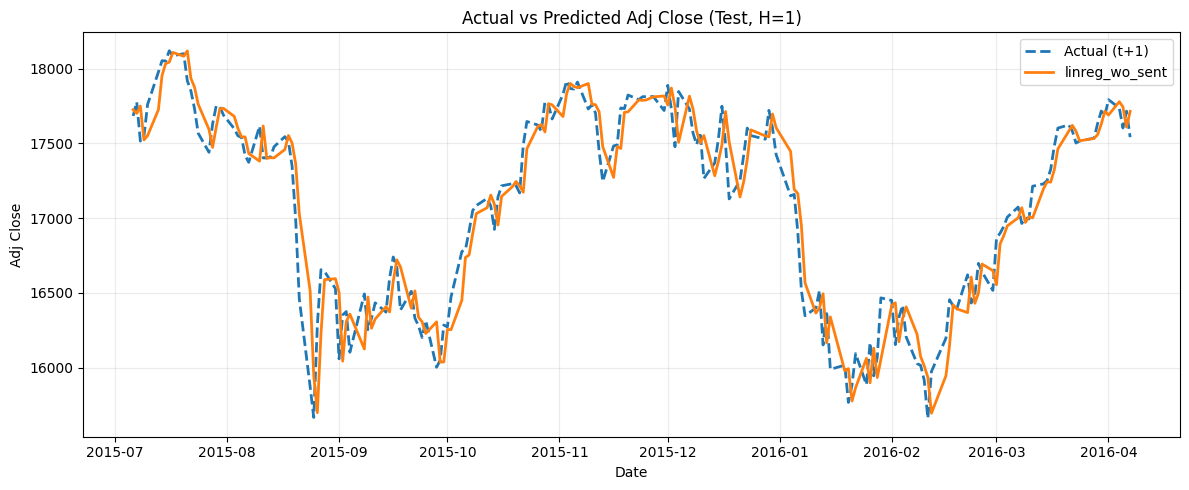

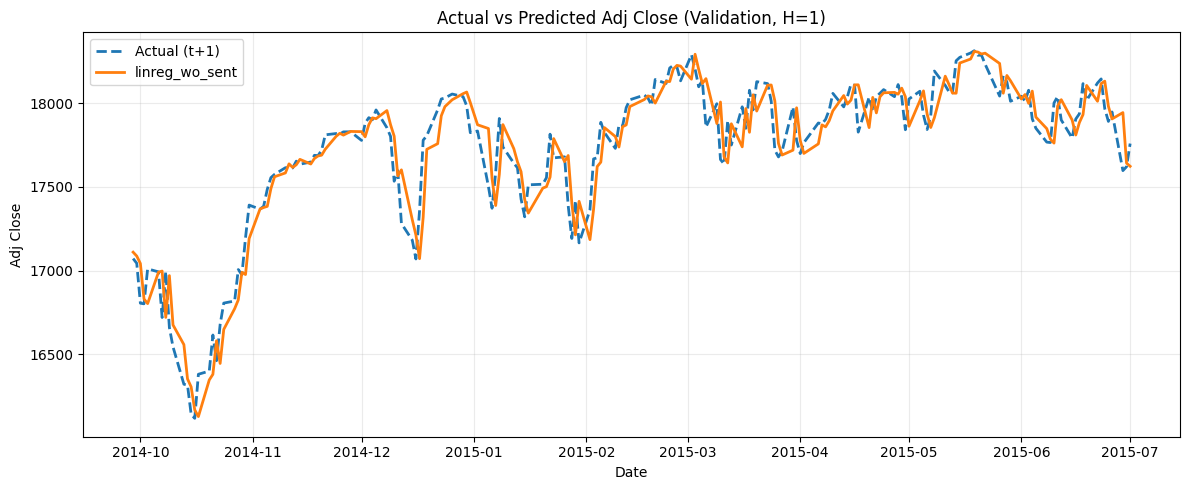

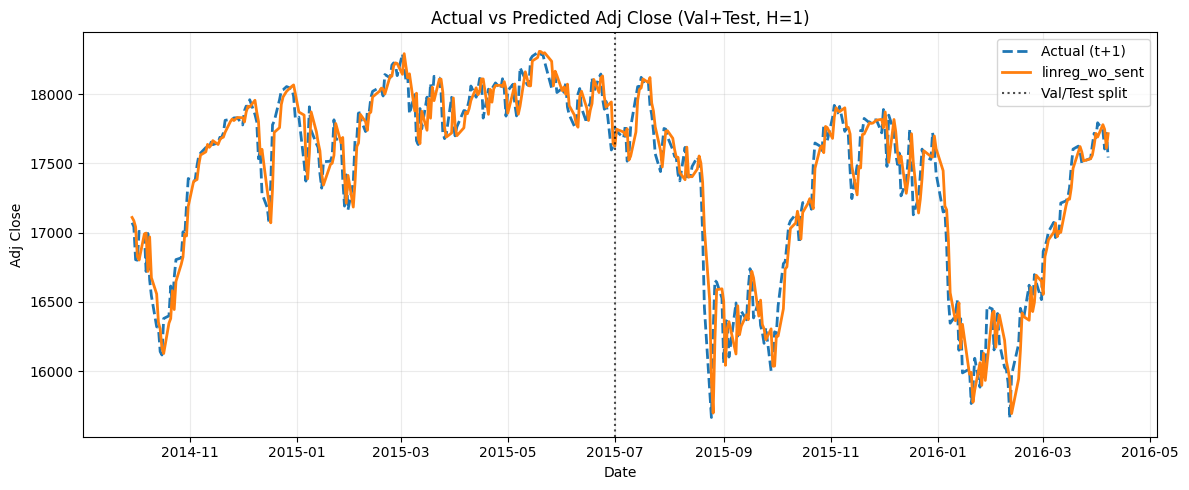

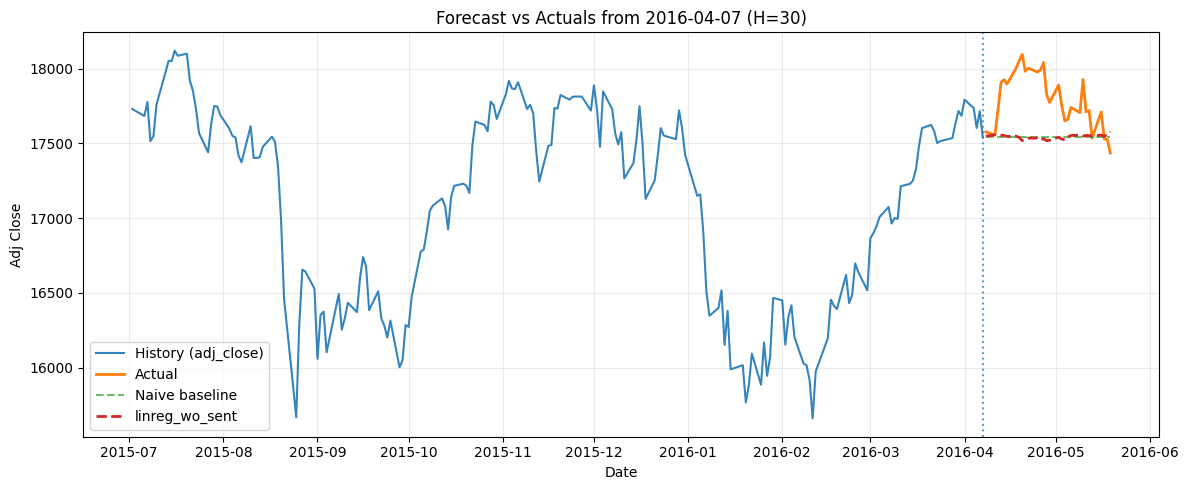

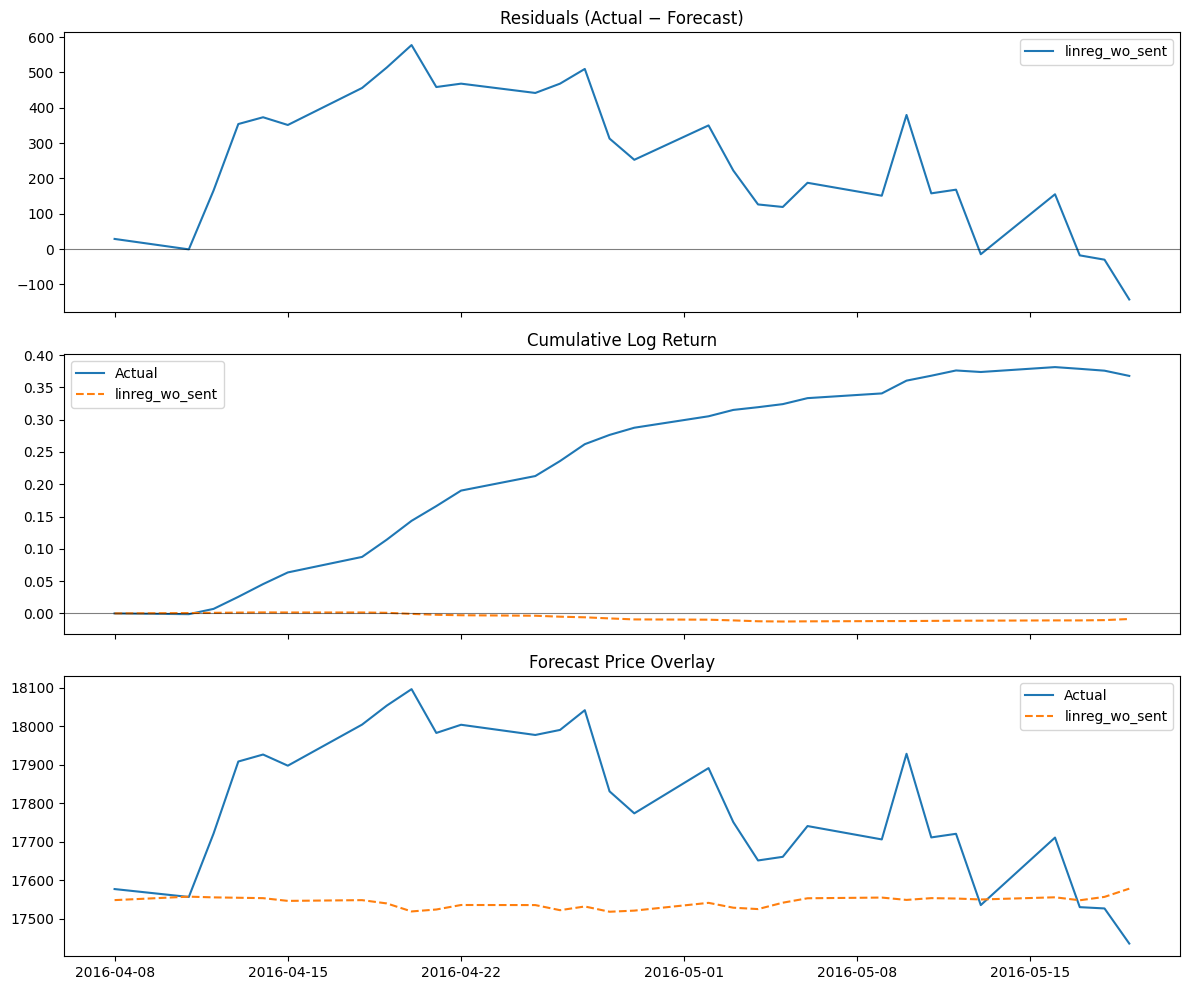

In [7]:
plot_test_overlay(test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close.png")
plot_val_overlay(val, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close_val.png")
plot_val_test_overlay(val, test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close_val_test.png")
plot_forecast_overlay(test, forecast, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast.png")
plot_forecast_diagnostics(forecast, test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast_diagnostics.png")

In [8]:
pd.DataFrame(results[0]["best_params"], index=[0])

,alpha,l1_ratio,max_iter,selection,random_state
0,0.000233,0.785176,1500,cyclic,42


In [9]:
pd.DataFrame(results[0]["metrics"]["test"], index=[0])

,mae,mse,rmse,smape,r2
0,599.185881,590516.557822,768.450752,1.737612,-0.111889


In [10]:
study = results[0]["study"]

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()

In [11]:
basedir = Path(cfg.data.processed_dir)

with_df = pd.read_csv(basedir / "linreg_metrics_test.csv")
wo_df = pd.read_csv(basedir / "linreg_wo_sent_metrics_test.csv")

with_df["sentiment"] = "with"
wo_df["sentiment"] = "without"

res = pd.concat([with_df, wo_df], ignore_index=True)

metric_cols = ["mae", "mse", "rmse", "smape", "r2"]

long_df = res[["name", "sentiment"] + metric_cols].round(6)
display(long_df.sort_values(["name", "sentiment"]))

,name,sentiment,mae,mse,rmse,smape,r2
0,linreg,with,591.703107,571948.618995,756.272847,1.656269,-0.076927
1,linreg_wo_sent,without,599.185881,590516.557822,768.450752,1.737612,-0.111889
